In [ ]:
# RFM Customer Segmentation
Scoring 4,338 customers by Recency, Frequency and Monetary value
to identify VIP, Loyal, At-Risk and Lost customer segments.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load and clean data — same steps as notebook 01
df = pd.read_csv('../data/online_retail.csv', encoding='latin-1')

# Clean
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"Data loaded: {df.shape[0]:,} rows")
print(f"Date range: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")

Data loaded: 397,884 rows
Date range: 2010-12-01 → 2011-12-09


In [2]:
# Snapshot date = 1 day after last transaction in dataset
# This is our "today" for calculating recency
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

# Calculate RFM metrics — one row per customer
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),   # unique orders, not rows
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(f"\nRFM table shape: {rfm.shape}")
print(f"\nSample:")
rfm.head()

Snapshot date: 2011-12-10

RFM table shape: (4338, 4)

Sample:


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [3]:
# Score each dimension 1-4 using quartiles
# Recency: LOWER days = BETTER = score 4 (reversed)
# Frequency: HIGHER orders = BETTER = score 4
# Monetary: HIGHER spend = BETTER = score 4

rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1,2,3,4])

# Combine into single RFM score string e.g. "444" = perfect customer
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) +
                    rfm['F_Score'].astype(str) +
                    rfm['M_Score'].astype(str))

# Total score out of 12
rfm['Total_Score'] = (rfm['R_Score'].astype(int) +
                      rfm['F_Score'].astype(int) +
                      rfm['M_Score'].astype(int))

print("Score distribution:")
print(rfm[['R_Score','F_Score','M_Score','RFM_Score','Total_Score']].head(8))

Score distribution:
  R_Score F_Score M_Score RFM_Score  Total_Score
0       1       1       4       114            6
1       4       4       4       444           12
2       2       3       4       234            9
3       3       1       4       314            8
4       1       1       2       112            4
5       3       4       4       344           11
6       1       1       1       111            3
7       1       1       3       113            5


In [4]:
# Assign business segments based on total score
def assign_segment(score):
    if score >= 10:
        return 'VIP'
    elif score >= 7:
        return 'Loyal'
    elif score >= 4:
        return 'At-Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['Total_Score'].apply(assign_segment)

# Summary of segments
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count = ('CustomerID', 'count'),
    Avg_Recency    = ('Recency',    'mean'),
    Avg_Frequency  = ('Frequency',  'mean'),
    Total_Revenue  = ('Monetary',   'sum')
).round(1).reset_index()

# Add % of customers
segment_summary['Pct_Customers'] = (
    segment_summary['Customer_Count'] /
    segment_summary['Customer_Count'].sum() * 100
).round(1)

print(segment_summary.to_string(index=False))

Segment  Customer_Count  Avg_Recency  Avg_Frequency  Total_Revenue  Pct_Customers
At-Risk            1492        145.7            1.3       645858.2           34.4
   Lost             303        267.8            1.0        49455.4            7.0
  Loyal            1275         60.9            2.9      1372049.5           29.4
    VIP            1268         19.9            9.9      6844044.8           29.2


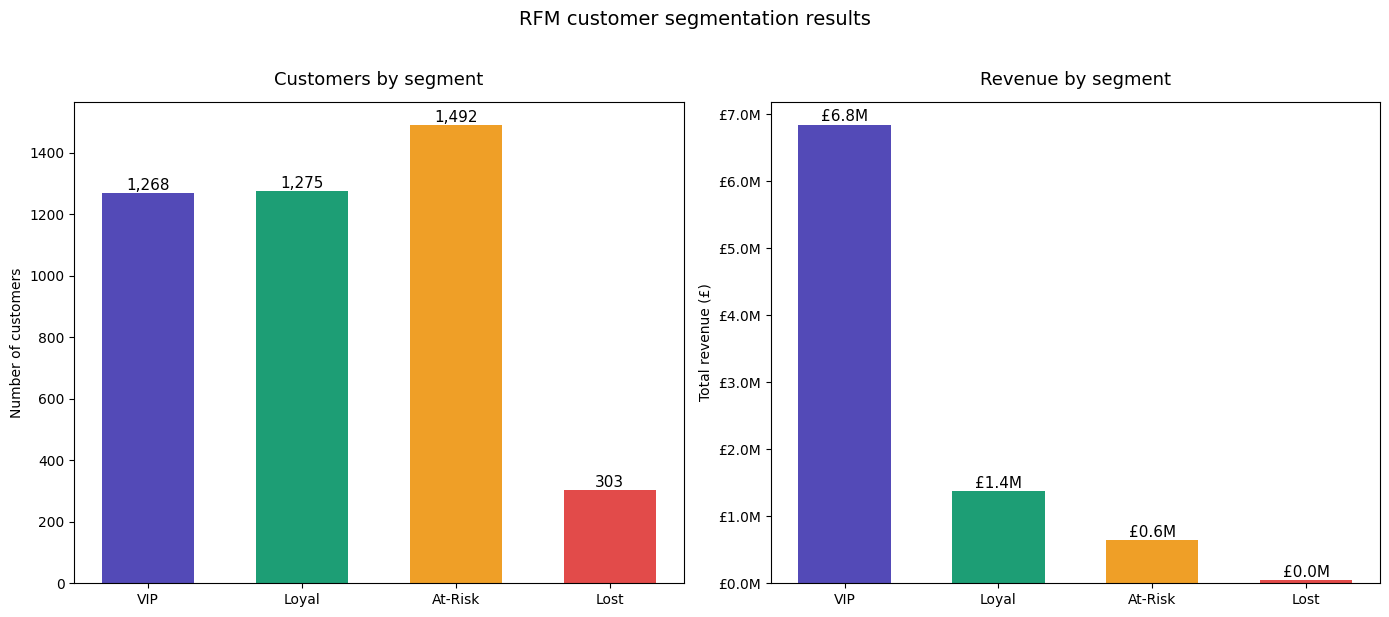

Chart saved!


In [5]:
# Colors for each segment — consistent across all charts
seg_colors = {
    'VIP':     '#534AB7',
    'Loyal':   '#1D9E75',
    'At-Risk': '#EF9F27',
    'Lost':    '#E24B4A'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Customer count by segment
order = ['VIP', 'Loyal', 'At-Risk', 'Lost']
counts = [segment_summary.loc[segment_summary['Segment']==s,
          'Customer_Count'].values[0] for s in order]
colors = [seg_colors[s] for s in order]

axes[0].bar(order, counts, color=colors, edgecolor='none', width=0.6)
axes[0].set_title('Customers by segment', fontsize=13, pad=12)
axes[0].set_ylabel('Number of customers')
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontsize=11)

# Chart 2 — Revenue by segment
revenues = [segment_summary.loc[segment_summary['Segment']==s,
            'Total_Revenue'].values[0] for s in order]

axes[1].bar(order, revenues, color=colors, edgecolor='none', width=0.6)
axes[1].set_title('Revenue by segment', fontsize=13, pad=12)
axes[1].set_ylabel('Total revenue (£)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
for i, v in enumerate(revenues):
    axes[1].text(i, v + 50000, f'£{v/1e6:.1f}M', ha='center', fontsize=11)

plt.suptitle('RFM customer segmentation results', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/charts/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

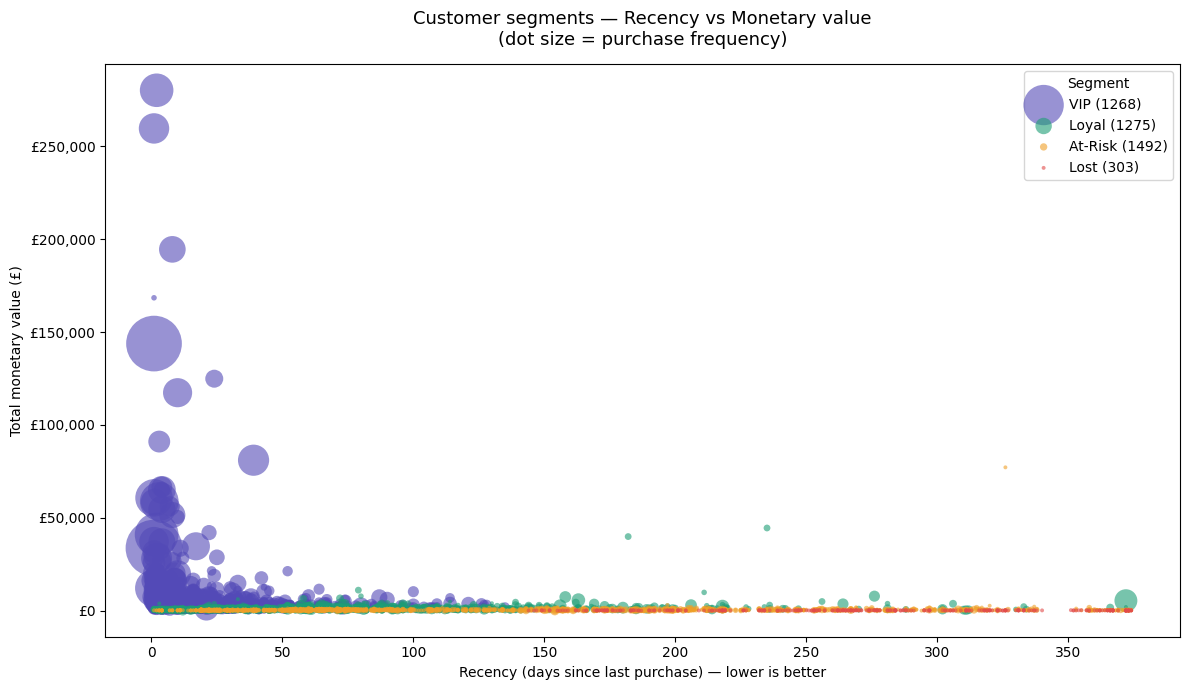

Chart saved!


In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

for segment in ['VIP', 'Loyal', 'At-Risk', 'Lost']:
    mask = rfm['Segment'] == segment
    ax.scatter(
        rfm.loc[mask, 'Recency'],
        rfm.loc[mask, 'Monetary'],
        c=seg_colors[segment],
        label=f"{segment} ({mask.sum()})",
        alpha=0.6,
        s=rfm.loc[mask, 'Frequency'] * 8,  # dot size = frequency
        edgecolors='none'
    )

ax.set_title('Customer segments — Recency vs Monetary value\n(dot size = purchase frequency)',
             fontsize=13, pad=14)
ax.set_xlabel('Recency (days since last purchase) — lower is better')
ax.set_ylabel('Total monetary value (£)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(title='Segment', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/charts/rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [7]:
total_rev = rfm['Monetary'].sum()
vip_rev = rfm[rfm['Segment']=='VIP']['Monetary'].sum()
atrisk_count = len(rfm[rfm['Segment']=='At-Risk'])

print("=" * 55)
print("KEY FINDINGS — RFM CUSTOMER SEGMENTATION")
print("=" * 55)
print(f"Total customers analysed:  {len(rfm):,}")
print(f"Total revenue:             £{total_rev:,.0f}")
print()
print(f"VIP customers:             {len(rfm[rfm['Segment']=='VIP']):,} ({len(rfm[rfm['Segment']=='VIP'])/len(rfm)*100:.1f}%)")
print(f"VIP revenue share:         £{vip_rev:,.0f} ({vip_rev/total_rev*100:.1f}% of total)")
print(f"VIP avg order frequency:   {rfm[rfm['Segment']=='VIP']['Frequency'].mean():.1f} orders")
print(f"VIP avg recency:           {rfm[rfm['Segment']=='VIP']['Recency'].mean():.0f} days")
print()
print(f"At-Risk customers:         {atrisk_count:,} ({atrisk_count/len(rfm)*100:.1f}%)")
print(f"At-Risk avg recency:       {rfm[rfm['Segment']=='At-Risk']['Recency'].mean():.0f} days")
print(f"Potential revenue at risk: £{rfm[rfm['Segment']=='At-Risk']['Monetary'].sum():,.0f}")
print("=" * 55)

KEY FINDINGS — RFM CUSTOMER SEGMENTATION
Total customers analysed:  4,338
Total revenue:             £8,911,408

VIP customers:             1,268 (29.2%)
VIP revenue share:         £6,844,045 (76.8% of total)
VIP avg order frequency:   9.9 orders
VIP avg recency:           20 days

At-Risk customers:         1,492 (34.4%)
At-Risk avg recency:       146 days
Potential revenue at risk: £645,858
